In [57]:
from dotenv import load_dotenv
import os 
import pygsheets
import tensorflow
from tensorflow import keras
import requests
import pandas as pd
from pangres import upsert
from sqlalchemy import text, create_engine
import time


load_dotenv()

api_key = os.environ.get("riot_api_key") #loads api key from .env file
response = requests.get(f"https://europe.api.riotgames.com/lol/match/v5/matches/EUW1_7714347614/timeline?api_key={api_key}")
print(response)
data = response.json()

<Response [200]>


In [58]:
def process_timeline_events_for_ml(timeline_data, match_data):
    #Extracting all metrics from the API into this record
    event_records = []

    blue_towers = 0
    red_towers = 0
    blue_dragons = 0
    red_dragons = 0
    blue_barons = 0
    red_barons = 0
    blue_kills = 0
    red_kills = 0
    
    match_id = match_data['metadata']['matchId']
    
    #Which team won
    teams = match_data['info']['teams']
    blue_won = 1 if teams[0]['win'] else 0  #1 if blue 0 if red wins
    
    for frame_idx, frame in enumerate(timeline_data['info']['frames']):
        timestamp = frame['timestamp']
        
        #At each frame calcuate all metrics
        blue_gold = 0
        red_gold = 0
        blue_xp = 0
        red_xp = 0
        blue_level = 0
        red_level = 0
        
        for participant_id, participant_frame in frame['participantFrames'].items():
            participant_id = int(participant_id)
            team = 100 if participant_id <= 5 else 200
            
            if team == 100:
                blue_gold += participant_frame['totalGold']
                blue_xp += participant_frame['xp']
                blue_level += participant_frame['level']
            else:
                red_gold += participant_frame['totalGold']
                red_xp += participant_frame['xp']
                red_level += participant_frame['level']
        
        #Process each event
        for event in frame.get('events', []):
            event_type = event['type']
            event_timestamp = event.get('timestamp', timestamp)
            
            # Update metric counters
            if event_type == 'BUILDING_KILL' and event.get('buildingType') == 'TOWER_BUILDING':
                if event['teamId'] == 100:
                    blue_towers += 1
                else:
                    red_towers += 1
            
            elif event_type == 'ELITE_MONSTER_KILL':
                monster_type = event['monsterType']
                killer_team = event.get('killerTeamId', 0)
                
                if monster_type == 'DRAGON':
                    if killer_team == 100:
                        blue_dragons += 1
                    else:
                        red_dragons += 1
                
                elif monster_type == 'BARON_NASHOR':
                    if killer_team == 100:
                        blue_barons += 1
                    else:
                        red_barons += 1
            
            elif event_type == 'CHAMPION_KILL':
                killer_team = event.get('killerTeamId', 0)
                if killer_team == 100:
                    blue_kills += 1
                else:
                    red_kills += 1
            
            #All events reocrded here 
            event_data = {
                'match_id': match_id,
                'frame_number': frame_idx,
                'timestamp_ms': event_timestamp,
                'timestamp_minutes': event_timestamp / 60000, #do this to match real time 
                'event_type': event_type,
                
                'blue_gold': blue_gold,
                'red_gold': red_gold,
                'gold_diff': blue_gold - red_gold,
                'blue_xp': blue_xp,
                'red_xp': red_xp,
                'xp_diff': blue_xp - red_xp,
                
                'blue_total_level': blue_level,
                'red_total_level': red_level,
                'level_diff': blue_level - red_level,
                
                'blue_towers': blue_towers,
                'red_towers': red_towers,
                'tower_diff': blue_towers - red_towers,
                'blue_dragons': blue_dragons,
                'red_dragons': red_dragons,
                'dragon_diff': blue_dragons - red_dragons,
                'blue_barons': blue_barons,
                'red_barons': red_barons,
                'baron_diff': blue_barons - red_barons,
                'blue_kills': blue_kills,
                'red_kills': red_kills,
                'kill_diff': blue_kills - red_kills,
                
                'blue_won': blue_won
            }
            event_records.append(event_data)
    
    return pd.DataFrame(event_records)




In [59]:
def get_match_data_from_id(region=None, matchId=None, api_key=None):
    root_url = f"https://{region}.api.riotgames.com/"
    endpoint = f"lol/match/v5/matches/{matchId}"
    response = requests.get(root_url + endpoint + "?api_key=" + api_key)
    
    if response.status_code != 200:
        print(f"Error caught, error code is : {response.status_code}")
        return None
    
    return response.json()

def get_match_timeline(region, matchId, api_key):
    #get timelien data for a match here, call this to get the timeline
    root_url = f"https://{region}.api.riotgames.com/"
    endpoint = f"lol/match/v5/matches/{matchId}/timeline"
    
    response = requests.get(root_url + endpoint + "?api_key=" + api_key)
    
    if response.status_code == 429:  #If rate limited, can happen if no timer between API gets 
        print("Rate limited by the API. Waiting 1 second")
        time.sleep(1)
        return get_match_timeline(region, matchId, api_key)
    
    if response.status_code != 200:
        print(f"Error caught, error code is : {response.status_code}")
        return None
    
    return response.json()

def process_single_match_timeline(matchId, region="europe", api_key=None):
   #process a timeline for a single match only
    try:
        match_data = get_match_data_from_id(region=region, matchId=matchId, api_key=api_key)
                
        timeline_data = get_match_timeline(region=region, matchId=matchId, api_key=api_key)
        
        timeline_df = process_timeline_events_for_ml(timeline_data, match_data)
        
        return timeline_df
        
    except Exception as e:
        print(f"Error processing the match {matchId}")
        return None

In [60]:
result_df = process_single_match_timeline(matchId="EUW1_7759435828", api_key=api_key)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(result_df)

print(result_df)

,match_id,frame_number,timestamp_ms,timestamp_minutes,event_type,blue_gold,red_gold,gold_diff,blue_xp,red_xp,xp_diff,blue_total_level,red_total_level,level_diff,blue_towers,red_towers,tower_diff,blue_dragons,red_dragons,dragon_diff,blue_barons,red_barons,baron_diff,blue_kills,red_kills,kill_diff,blue_won
0,EUW1_7759435828,0,0,0.000000,PAUSE_END,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,EUW1_7759435828,0,0,0.000000,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,EUW1_7759435828,0,0,0.000000,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,EUW1_7759435828,1,1855,0.030917,SKILL_LEVEL_UP,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,EUW1_7759435828,1,4260,0.071000,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,EUW1_7759435828,1,4728,0.078800,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,EUW1_7759435828,1,5608,0.093467,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,EUW1_7759435828,1,5608,0.093467,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,EUW1_7759435828,1,7379,0.122983,SKILL_LEVEL_UP,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,EUW1_7759435828,1,8848,0.147467,ITEM_PURCHASED,2500,2500,0,0,0,0,5,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0


            match_id  frame_number  timestamp_ms  timestamp_minutes  \
0    EUW1_7759435828             0             0           0.000000   
1    EUW1_7759435828             0             0           0.000000   
2    EUW1_7759435828             0             0           0.000000   
3    EUW1_7759435828             1          1855           0.030917   
4    EUW1_7759435828             1          4260           0.071000   
5    EUW1_7759435828             1          4728           0.078800   
6    EUW1_7759435828             1          5608           0.093467   
7    EUW1_7759435828             1          5608           0.093467   
8    EUW1_7759435828             1          7379           0.122983   
9    EUW1_7759435828             1          8848           0.147467   
10   EUW1_7759435828             1          8848           0.147467   
11   EUW1_7759435828             1          9116           0.151933   
12   EUW1_7759435828             1          9283           0.154717   
13   E

In [61]:
import random
import time

def get_match_history(region=None, puuid=None, start=0, count=50):

    root_url = f"https://{region}.api.riotgames.com/"
    endpoint = f"lol/match/v5/matches/by-puuid/{puuid}/ids"
    query_params = f"?start={start}&count={count}"
    response = requests.get(root_url+endpoint+query_params+"&api_key="+api_key)
    print(response)
    return response.json()

def collect_matches_multirank(num_matches=500):
    #This function collects all ranks, for single rank will be other functions
    match_id_collection = set() 
    headers = {"X-Riot-Token": api_key}  
    ranks = [("PLATINUM", "I"),]  
    matches_per_rank = num_matches // len(ranks)
    
    for tier, division in ranks:
        print(f"Collecting games from {tier}, {division}")
        rank_matches = set()
        page = 1
        players_used = set()#Track players incase we take more than one from them
        
        while len(rank_matches) < matches_per_rank:
            response = requests.get(f"https://euw1.api.riotgames.com/lol/league/v4/entries/RANKED_SOLO_5x5/{tier}/{division}?page={page}", headers=headers)
           
            if response.status_code != 200:
                print(f"Error: {response.status_code}")
                break

            players = response.json()

            if len(players) == 0:
                print(f"No more players on page {page}")
                break
            
            available_players = [p for p in players if p['puuid'] not in players_used]#Try user players we havent already used to not create patterns on purpose
            
            if len(available_players) == 0:
                page += 1  #Move pages when done with page
                continue
           
            sample_size = min(20, len(available_players))#Take only 20 players from here
            reviewed_players = random.sample(available_players, sample_size)

            for player in reviewed_players:
                puuid = player['puuid']
                players_used.add(puuid)
                #get player Id's then use pre existing function to get their match history, therefore automating the data collection process
                matches = get_match_history(region="europe", puuid=puuid, count=50)#only getting 50 to not create too much of a pattern in the data collection proccess
                rank_matches.update(matches)            
                if len(rank_matches) >= matches_per_rank:#before we take too many matches for each rank break 
                    break
                time.sleep(1.2)#to not overload riot API
            
            if len(rank_matches) >= matches_per_rank:#before we take too many matches for each rank break
                break
            
            page += 1  #Move pages when don e with page
        
        match_id_collection.update(rank_matches)
    
    return list(match_id_collection)[:num_matches]

In [62]:
#Get ids here
match_ids = collect_matches_multirank(num_matches=5000)
print(f"Collected {len(match_ids)} match IDs")


def process_multiple_matches(match_ids, api_key):
    #process multiple matches at once
    all_timelines = []
    
    for i, match_id in enumerate(match_ids):
        print(f"\nProcessing {i+1}/{len(match_ids)}: {match_id}")
        
        try:
            timeline_df = process_single_match_timeline(matchId=match_id,  region="europe", api_key=api_key)
            
            if timeline_df is not None and not timeline_df.empty:
                all_timelines.append(timeline_df)
                print(f"Added {len(timeline_df)} events")
            else:
                print(f"No data for {match_id}")
                
        except Exception as e:
            print(f"Error processing {match_id}: {e}")
            continue
        
        #Rate limiting for RIOT API
        time.sleep(1.2)
    
    #Combine all DataFrames into one
    if all_timelines:
        combined_df = pd.concat(all_timelines, ignore_index=True)
        print(f"TOTAL: {len(all_timelines)} matches processed")
        print(f"TOTAL: {len(combined_df)} events")
        return combined_df
    else:
        print("No data collected!")
        return pd.DataFrame()

all_game_data = process_multiple_matches(match_ids, api_key)

#Save everything to csv to use in processing
all_game_data.to_csv('all_matches_timeline_data.csv', index=False)
print("\nSaved to 'all_matches_timeline_data.csv'")

<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200

Loaded 5659721 events from 4989 matches from the csv file

Train set: 4527776 samples
Test set: 1131945 samples

Model Architecture:


d:\Turning Point\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)


Training model under here
Epoch 1/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 58s 1ms/step - accuracy: 0.7306 - auc: 0.8220 - loss: 0.5052 - val_accuracy: 0.7357 - val_auc: 0.8272 - val_loss: 0.4997
Epoch 2/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 58s 1ms/step - accuracy: 0.7337 - auc: 0.8257 - loss: 0.5005 - val_accuracy: 0.7390 - val_auc: 0.8308 - val_loss: 0.4948
Epoch 3/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 57s 1ms/step - accuracy: 0.7353 - auc: 0.8276 - loss: 0.4980 - val_accuracy: 0.7405 - val_auc: 0.8330 - val_loss: 0.4913
Epoch 4/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 57s 1ms/step - accuracy: 0.7365 - auc: 0.8288 - loss: 0.4964 - val_accuracy: 0.7420 - val_auc: 0.8348 - val_loss: 0.4924
Epoch 5/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 57s 1ms/step - accuracy: 0.7372 - auc: 0.8298 - loss: 0.4951 - val_accuracy: 0.7437 - val_auc: 0.8365 - val_loss: 0.4883
Epoch 6/50
56598/56598 ━━━━━━━━━━━━━━━━━━━━ 58s 1ms/step - accuracy: 0.7380 - auc: 0.8305 - loss: 0.4943 - val_accuracy: 0.7439 - val_auc: 0.8370 - 

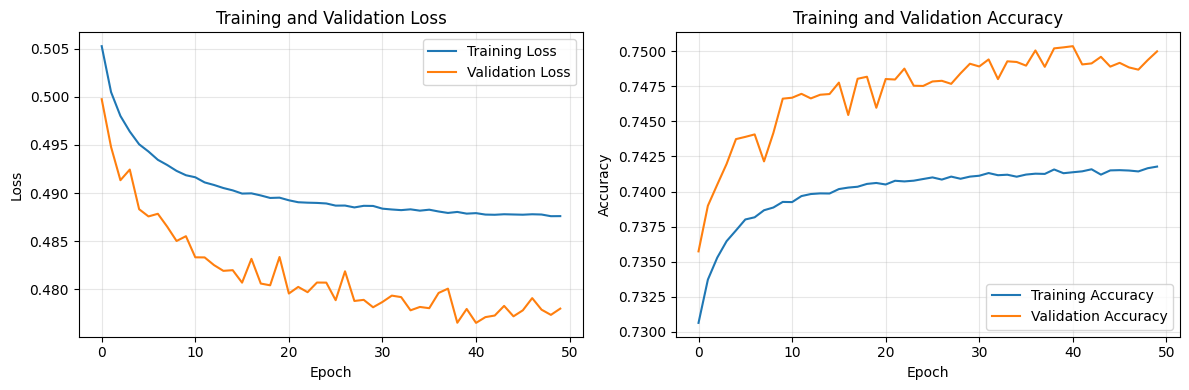


✓ Model saved as 'lol_win_predictor.keras'
✓ Scaler saved as 'scaler.pkl'


In [63]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle

#Load data from csv file
df = pd.read_csv('all_matches_timeline_data.csv')
print(f"Loaded {len(df)} events from {df['match_id'].nunique()} matches from the csv file")

#Prepare statistics needed
feature_columns = [
    'timestamp_minutes',
    'gold_diff',
    'xp_diff',
    'level_diff',
    'kill_diff',
    'tower_diff',
    'dragon_diff',
    'baron_diff'
]

X = df[feature_columns].values
y = df['blue_won'].values

#split and scale the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

#Model build here, using RELU, and sigmoid. 
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(len(feature_columns),)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  #Output probability [0,1]
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\nModel Architecture:")
model.summary()

#Train the model here
print("\nTraining model under here")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

#Evaluate the model here
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test)
print(f"\n{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"{'='*50}")

#Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

#Save the model to be used
model.save('lol_win_predictor.keras')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✓ Model saved as 'lol_win_predictor.keras'")
print("✓ Scaler saved as 'scaler.pkl'")

Processing EUW1_7772271731


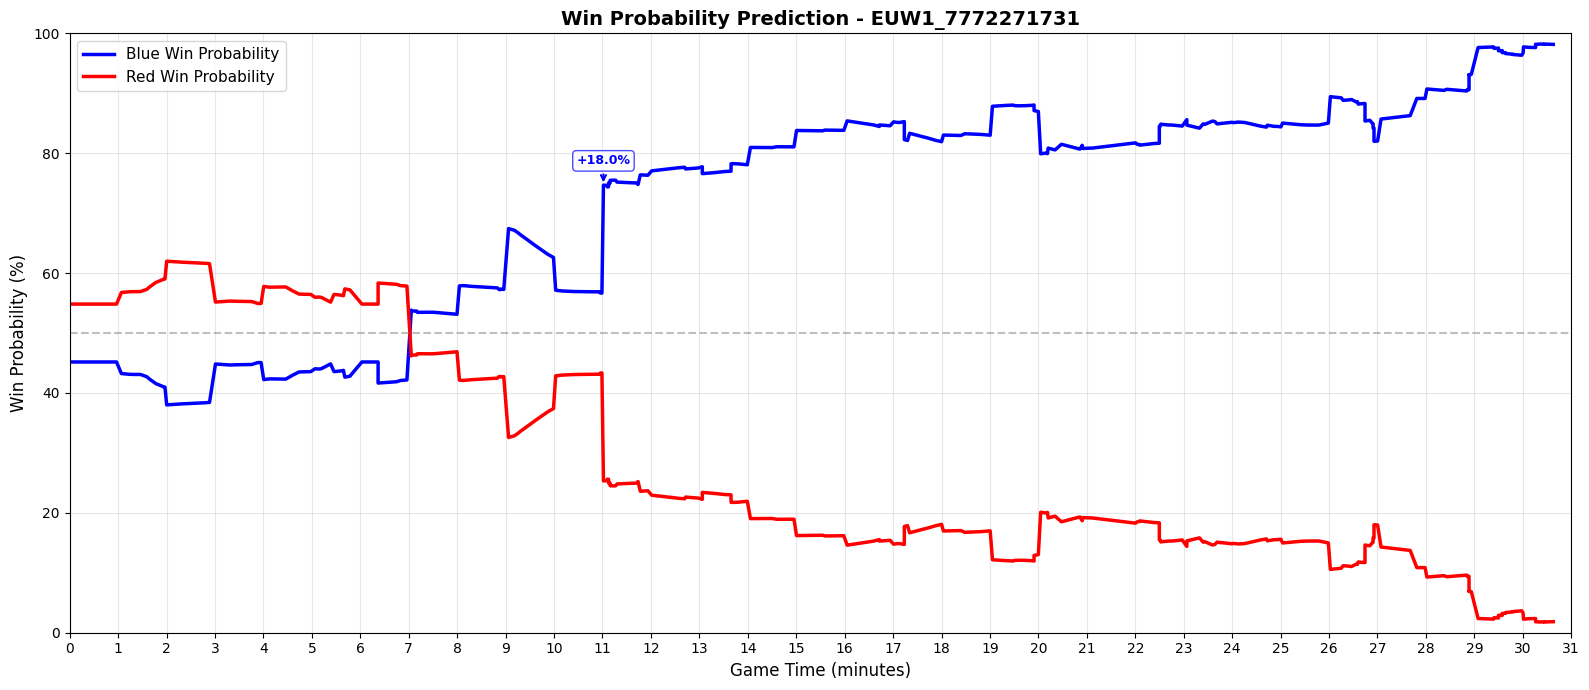


Final prediction: Blue 98.2% | Red 1.8%
MAJOR CHANGE POINTS (>15% probability swing)
⚡ BLUE GAINED 18.0% at 11.02 minutes
   Blue: 56.7% → 74.7%

 Events in the 30 seconds leading to this swing:
   • 10.96 min: KILL → Kill score: 0-10 (Diff: -10)

  Gold at this moment: Blue 20,388 vs Red 18,311 (Diff: +2,077)
KILLS, OBJECTIVES & GOLD EVENTS


,timestamp_minutes,event_type,blue_kills,red_kills,kill_diff,blue_gold,red_gold,gold_diff,blue_towers,red_towers,tower_diff,blue_dragons,red_dragons,blue_barons,red_barons,blue_win_prob,red_win_prob
174,5.457967,CHAMPION_KILL,0,1,-1,9737,10252,-515,0,0,0,0,0,0,0,0.435646,0.564354
179,5.660317,CHAMPION_KILL,0,2,-2,9737,10252,-515,0,0,0,0,0,0,0,0.434542,0.565458
180,5.682033,CHAMPION_KILL,0,3,-3,9737,10252,-515,0,0,0,0,0,0,0,0.426405,0.573595
198,6.368133,ELITE_MONSTER_KILL,0,3,-3,11672,11629,43,0,0,0,0,1,0,0,0.416572,0.583428
210,6.838200,CHAMPION_KILL,0,4,-4,11672,11629,43,0,0,0,0,1,0,0,0.420967,0.579033
214,7.061017,CHAMPION_KILL,0,5,-5,14255,13110,1145,0,0,0,0,1,0,0,0.536686,0.463314
222,7.180633,CHAMPION_KILL,0,6,-6,14255,13110,1145,0,0,0,0,1,0,0,0.534519,0.465481
282,8.623100,ELITE_MONSTER_KILL,0,6,-6,16851,14956,1895,0,0,0,0,1,0,0,0.576186,0.423814
291,8.799933,ELITE_MONSTER_KILL,0,6,-6,16851,14956,1895,0,0,0,0,1,0,0,0.575428,0.424572
292,8.831117,ELITE_MONSTER_KILL,0,6,-6,16851,14956,1895,0,0,0,0,1,0,0,0.575294,0.424706



SUMMARY STATISTICS

Total important events: 78

Champion Kills: 53

Objectives (Dragon/Baron): 10

Buildings (Towers): 15

Game duration: 30.6 minutes

Final Stats:

Blue: 0 kills, 70,576 gold, 2 towers

 Red:  53 kills, 55,731 gold, 11 towers

Win probability:

Blue: 98.2%

Red:  1.8%

TOP GAME-CHANGING MOMENTS


In [64]:
def predict_new_match(match_id, api_key):

    model = keras.models.load_model('lol_win_predictor.keras')
    with open('scaler.pkl', 'rb') as f: scaler = pickle.load(f)
    print(f"Processing {match_id}")
    timeline_df = process_single_match_timeline(match_id, region="europe", api_key=api_key)
    if timeline_df is None or timeline_df.empty:
        print("No match data in this match")#incase o=f no match data
        return
    
    X_new = timeline_df[feature_columns].values
    X_new_scaled = scaler.transform(X_new)
    win_probs = model.predict(X_new_scaled, verbose=0)#verbose 0 for no imformation, change to 1 for deatails during prediction
    
    timeline_df['blue_win_prob'] = win_probs
    timeline_df['red_win_prob'] = 1 - win_probs
    timeline_df['blue_prob_change'] = timeline_df['blue_win_prob'].diff()
    
    threshold = 0.15 #this controls the percentage in which a win probability changes drastically, change for sensitivity regarding change points
    change_points = timeline_df[abs(timeline_df['blue_prob_change']) > threshold].copy()#set change point here
    
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(timeline_df['timestamp_minutes'], timeline_df['blue_win_prob'] * 100, label='Blue Win Probability', color='blue', linewidth=2.5)#change line width to need
    ax.plot(timeline_df['timestamp_minutes'], timeline_df['red_win_prob'] * 100, label='Red Win Probability', color='red', linewidth=2.5)
    
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    for idx, row in change_points.iterrows():#for change point annotate
        time = row['timestamp_minutes']
        prob = row['blue_win_prob'] * 100
        change = row['blue_prob_change'] * 100
        color = 'blue' if change > 0 else 'red'
        
        ax.annotate(f'{change:+.1f}%', 
                   xy=(time, prob),
                   xytext=(0, 15 if change > 0 else -15),
                   textcoords='offset points',
                   ha='center',
                   fontsize=9,
                   color=color,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.7),
                   arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    max_time = int(timeline_df['timestamp_minutes'].max()) + 1#adding time to graph
    ax.set_xticks(range(0, max_time + 1, 1))
    ax.set_xlim(0, max_time)   
    ax.set_xlabel('Game Time (minutes)', fontsize=12)
    ax.set_ylabel('Win Probability (%)', fontsize=12)
    ax.set_title(f'Win Probability Prediction - {match_id}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()  
    print(f"\nFinal prediction: Blue {timeline_df['blue_win_prob'].iloc[-1]:.1%} | Red {timeline_df['red_win_prob'].iloc[-1]:.1%}")

    if len(change_points) > 0:
        print(f"MAJOR CHANGE POINTS (>{threshold*100:.0f}% probability swing)")

        for idx, swing in change_points.iterrows():#for each change point
            swing_time = swing['timestamp_minutes']
            swing_time_ms = swing['timestamp_ms']
            change = swing['blue_prob_change'] * 100
            team = "BLUE" if change > 0 else "RED"
            print(f"⚡ {team} GAINED {abs(change):.1f}% at {swing_time:.2f} minutes")
            print(f"   Blue: {(swing['blue_win_prob'] - swing['blue_prob_change'])*100:.1f}% → {swing['blue_win_prob']*100:.1f}%")
           
            change_point_start_ms = swing_time_ms - 30000 
            game_events = timeline_df[
                (timeline_df['timestamp_ms'] >= change_point_start_ms) & 
                (timeline_df['timestamp_ms'] <= swing_time_ms) &
                (timeline_df['event_type'].isin(['CHAMPION_KILL', 'ELITE_MONSTER_KILL', 'BUILDING_KILL']))
            ]
            
            if len(game_events) > 0:
                print(f"\n Events in the 30 seconds leading to this swing:")
                for _, event in game_events.iterrows():
                    event_time = event['timestamp_minutes']
                    event_type = event['event_type']
                    
                    if event_type == 'CHAMPION_KILL':
                        print(f"   • {event_time:.2f} min: KILL → Kill score: {event['blue_kills']}-{event['red_kills']} (Diff: {event['kill_diff']:+d})")
                    elif event_type == 'ELITE_MONSTER_KILL':
                        print(f"   • {event_time:.2f} min: OBJECTIVE → Dragons: {event['blue_dragons']}-{event['red_dragons']}, Barons: {event['blue_barons']}-{event['red_barons']}")
                    elif event_type == 'BUILDING_KILL':
                        print(f"   • {event_time:.2f} min: TOWER → Towers: {event['blue_towers']}-{event['red_towers']} (Diff: {event['tower_diff']:+d})")

                final_event = game_events.iloc[-1]
                print(f"\n  Gold at this moment: Blue {final_event['blue_gold']:,} vs Red {final_event['red_gold']:,} (Diff: {final_event['gold_diff']:+,})")
            else:
                print(f"\n  No major events in the 30 seconds before this swing")
    
    important_events = timeline_df[timeline_df['event_type'].isin([
        'CHAMPION_KILL',
        'ELITE_MONSTER_KILL',
        'BUILDING_KILL'
    ])].copy()
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("KILLS, OBJECTIVES & GOLD EVENTS")
    
    key_columns = [
        'timestamp_minutes', 
        'event_type', 
        'blue_kills', 'red_kills', 'kill_diff',
        'blue_gold', 'red_gold', 'gold_diff',
        'blue_towers', 'red_towers', 'tower_diff',
        'blue_dragons', 'red_dragons', 
        'blue_barons', 'red_barons',
        'blue_win_prob', 'red_win_prob'
    ]
    display(important_events[key_columns])
    
    print("\nSUMMARY STATISTICS")
    print(f"\nTotal important events: {len(important_events)}")
    print(f"\nChampion Kills: {(important_events['event_type'] == 'CHAMPION_KILL').sum()}")
    print(f"\nObjectives (Dragon/Baron): {(important_events['event_type'] == 'ELITE_MONSTER_KILL').sum()}")
    print(f"\nBuildings (Towers): {(important_events['event_type'] == 'BUILDING_KILL').sum()}")
    print(f"\nGame duration: {timeline_df['timestamp_minutes'].max():.1f} minutes")
    
    print(f"\nFinal Stats:")
    print(f"\nBlue: {important_events['blue_kills'].iloc[-1]} kills, {important_events['blue_gold'].iloc[-1]:,} gold, {important_events['blue_towers'].iloc[-1]} towers")
    print(f"\n Red:  {important_events['red_kills'].iloc[-1]} kills, {important_events['red_gold'].iloc[-1]:,} gold, {important_events['red_towers'].iloc[-1]} towers")
    
    print(f"\nWin probability:")
    print(f"\nBlue: {timeline_df['blue_win_prob'].iloc[-1]:.1%}")
    print(f"\nRed:  {timeline_df['red_win_prob'].iloc[-1]:.1%}")
    
    #Find important change point moments
    print(f"\n{'='*80}")
    print("TOP GAME-CHANGING MOMENTS")
    print(f"{'='*80}")

    
new_match = predict_new_match("EUW1_7772271731", api_key)

In [68]:
def plot_predictions(match_id, api_key):

            
    model = keras.models.load_model('lol_win_predictor.keras')
    with open('scaler.pkl', 'rb') as f: scaler = pickle.load(f)
    print(f"Processing {match_id}")
    timeline_df = process_single_match_timeline(match_id, region="europe", api_key=api_key)
    if timeline_df is None or timeline_df.empty:
        print("No match data in this match")#incase o=f no match data
        return
    
    X_new = timeline_df[feature_columns].values
    X_new_scaled = scaler.transform(X_new)
    win_probs = model.predict(X_new_scaled, verbose=0)#verbose 0 for no imformation, change to 1 for deatails during prediction

    timeline_df['blue_win_prob'] = win_probs
    timeline_df['red_win_prob'] = 1 - win_probs
    timeline_df['blue_prob_change'] = timeline_df['blue_win_prob'].diff()
    threshold = 0.15 #this controls the percentage in which a win probability changes drastically, change for sensitivity regarding change points

    fig, ax = plt.subplots(figsize=(16, 7)) 



    ax.plot(timeline_df['timestamp_minutes'], timeline_df['blue_win_prob'] * 100, 
            label='Blue Win Probability', color='blue', linewidth=2.5)
    ax.plot(timeline_df['timestamp_minutes'], timeline_df['red_win_prob'] * 100, 
            label='Red Win Probability', color='red', linewidth=2.5)



    timeline_df['blue_win_prob'] = win_probs
    timeline_df['red_win_prob'] = 1 - win_probs
    timeline_df['blue_prob_change'] = timeline_df['blue_win_prob'].diff()
    
    max_time = int(timeline_df['timestamp_minutes'].max()) + 1#adding time to graph
    ax.set_xticks(range(0, max_time + 1, 1))
    ax.set_xlim(0, max_time)   
    ax.set_xlabel('Game Time (minutes)', fontsize=12)
    ax.set_ylabel('Win Probability (%)', fontsize=12)
    ax.set_title(f'Win Probability Prediction - {match_id}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()  
    print(f"\nFinal prediction: Blue {timeline_df['blue_win_prob'].iloc[-1]:.1%} | Red {timeline_df['red_win_prob'].iloc[-1]:.1%}")


    important_events = timeline_df[timeline_df['event_type'].isin([
        'CHAMPION_KILL',
        'ELITE_MONSTER_KILL',
        'BUILDING_KILL'
    ])].copy()
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("KILLS, OBJECTIVES & GOLD EVENTS")
    
    key_columns = [
        'timestamp_minutes', 
        'event_type', 
        'blue_kills', 'red_kills', 'kill_diff',
        'blue_gold', 'red_gold', 'gold_diff',
        'blue_towers', 'red_towers', 'tower_diff',
        'blue_dragons', 'red_dragons', 
        'blue_barons', 'red_barons',
        'blue_win_prob', 'red_win_prob'
    ]
    display(important_events[key_columns])
    
    print("\nSUMMARY STATISTICS")
    print(f"\nTotal important events: {len(important_events)}")
    print(f"\nChampion Kills: {(important_events['event_type'] == 'CHAMPION_KILL').sum()}")
    print(f"\nObjectives (Dragon/Baron): {(important_events['event_type'] == 'ELITE_MONSTER_KILL').sum()}")
    print(f"\nBuildings (Towers): {(important_events['event_type'] == 'BUILDING_KILL').sum()}")
    print(f"\nGame duration: {timeline_df['timestamp_minutes'].max():.1f} minutes")
    
    print(f"\nFinal Stats:")
    print(f"\nBlue: {important_events['blue_kills'].iloc[-1]} kills, {important_events['blue_gold'].iloc[-1]:,} gold, {important_events['blue_towers'].iloc[-1]} towers")
    print(f"\n Red:  {important_events['red_kills'].iloc[-1]} kills, {important_events['red_gold'].iloc[-1]:,} gold, {important_events['red_towers'].iloc[-1]} towers")
    
    print(f"\nWin probability:")
    print(f"\nBlue: {timeline_df['blue_win_prob'].iloc[-1]:.1%}")
    print(f"\nRed:  {timeline_df['red_win_prob'].iloc[-1]:.1%}")
    
    #Find important change point moments
    print("TOP GAME-CHANGING MOMENTS")
    find_change_points(timeline_df, ax)  
    
    plt.show()

def find_change_points(timeline_df, ax, threshold=0.15):
    change_points = timeline_df[abs(timeline_df['blue_prob_change']) > threshold].copy()
         
    if len(change_points) > 0:

        
        print(f"MAJOR CHANGE POINTS (>{threshold*100:.0f}% probability swing)")

        for idx, swing in change_points.iterrows():#for each change point
            swing_time = swing['timestamp_minutes']
            swing_time_ms = swing['timestamp_ms']
            change = swing['blue_prob_change'] * 100
            team = "BLUE" if change > 0 else "RED"
            print(f"{team} GAINED {abs(change):.1f}% at {swing_time:.2f} minutes")
            print(f"Blue: {(swing['blue_win_prob'] - swing['blue_prob_change'])*100:.1f}% → {swing['blue_win_prob']*100:.1f}%")
           
            change_point_start_ms = swing_time_ms - 30000 
            game_events = timeline_df[
                (timeline_df['timestamp_ms'] >= change_point_start_ms) & 
                (timeline_df['timestamp_ms'] <= swing_time_ms) &
                (timeline_df['event_type'].isin(['CHAMPION_KILL', 'ELITE_MONSTER_KILL', 'BUILDING_KILL']))
            ]
            
            if len(game_events) > 0:
                print(f"\n Events in the 30 seconds leading to this swing:")
                for _, event in game_events.iterrows():
                    event_time = event['timestamp_minutes']
                    event_type = event['event_type']
                    
                    if event_type == 'CHAMPION_KILL':
                        print(f"   • {event_time:.2f} min: KILL → Kill score: {event['blue_kills']}-{event['red_kills']} (Diff: {event['kill_diff']:+d})")
                    elif event_type == 'ELITE_MONSTER_KILL':
                        print(f"   • {event_time:.2f} min: OBJECTIVE → Dragons: {event['blue_dragons']}-{event['red_dragons']}, Barons: {event['blue_barons']}-{event['red_barons']}")
                    elif event_type == 'BUILDING_KILL':
                        print(f"   • {event_time:.2f} min: TOWER → Towers: {event['blue_towers']}-{event['red_towers']} (Diff: {event['tower_diff']:+d})")

                final_event = game_events.iloc[-1]
                print(f"\n  Gold at this moment: Blue {final_event['blue_gold']:,} vs Red {final_event['red_gold']:,} (Diff: {final_event['gold_diff']:+,})")
            else:
                print(f"\n  No major events in the 30 seconds before this swing")

def predict_new_match(match_id, api_key):
        plot_predictions("EUW1_7698286335", api_key)

Processing EUW1_7698286335


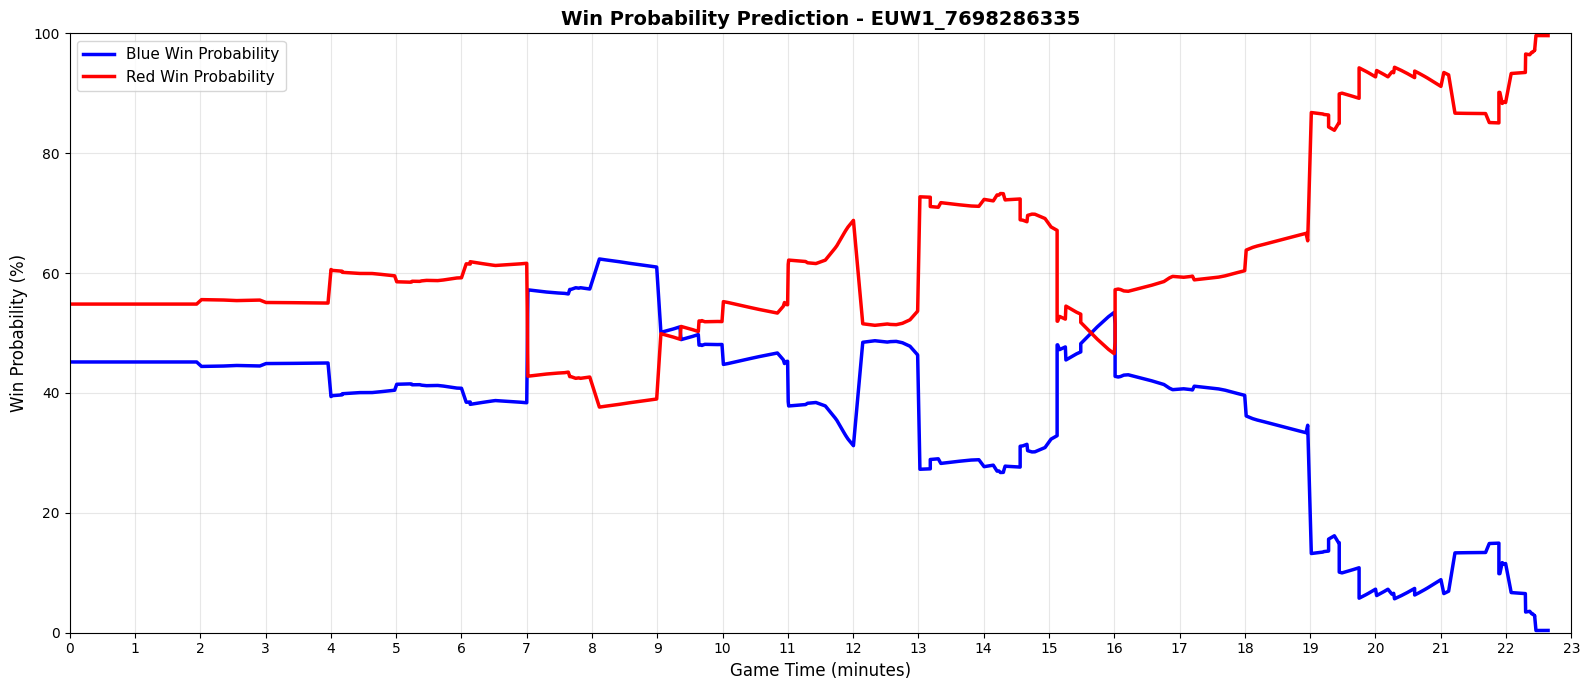


Final prediction: Blue 0.4% | Red 99.6%
KILLS, OBJECTIVES & GOLD EVENTS


,timestamp_minutes,event_type,blue_kills,red_kills,kill_diff,blue_gold,red_gold,gold_diff,blue_towers,red_towers,tower_diff,blue_dragons,red_dragons,blue_barons,red_barons,blue_win_prob,red_win_prob
123,3.936417,CHAMPION_KILL,0,1,-1,6706,7025,-319,0,0,0,0,0,0,0,0.450004,0.549996
130,4.013683,CHAMPION_KILL,0,2,-2,8625,9057,-432,0,0,0,0,0,0,0,0.395426,0.604574
140,4.174017,CHAMPION_KILL,0,3,-3,8625,9057,-432,0,0,0,0,0,0,0,0.397781,0.602219
142,4.176533,CHAMPION_KILL,0,4,-4,8625,9057,-432,0,0,0,0,0,0,0,0.398741,0.601259
158,4.634217,CHAMPION_KILL,0,5,-5,8625,9057,-432,0,0,0,0,0,0,0,0.400705,0.599295
180,5.246150,CHAMPION_KILL,0,6,-6,10449,10946,-497,0,0,0,0,0,0,0,0.413632,0.586368
188,5.392000,CHAMPION_KILL,0,7,-7,10449,10946,-497,0,0,0,0,0,0,0,0.412984,0.587016
189,5.466600,CHAMPION_KILL,0,8,-8,10449,10946,-497,0,0,0,0,0,0,0,0.412165,0.587835
195,5.532867,CHAMPION_KILL,0,9,-9,10449,10946,-497,0,0,0,0,0,0,0,0.412213,0.587787
218,6.135617,CHAMPION_KILL,0,10,-10,11987,13030,-1043,0,0,0,0,0,0,0,0.381016,0.618984



SUMMARY STATISTICS

Total important events: 66

Champion Kills: 47

Objectives (Dragon/Baron): 7

Buildings (Towers): 12

Game duration: 22.6 minutes

Final Stats:

Blue: 0 kills, 40,949 gold, 10 towers

 Red:  47 kills, 52,848 gold, 0 towers

Win probability:

Blue: 0.4%

Red:  99.6%
TOP GAME-CHANGING MOMENTS
MAJOR CHANGE POINTS (>15% probability swing)
BLUE GAINED 18.8% at 7.02 minutes
Blue: 38.4% → 57.2%

  No major events in the 30 seconds before this swing
BLUE GAINED 17.2% at 12.15 minutes
Blue: 31.2% → 48.5%

  No major events in the 30 seconds before this swing
RED GAINED 19.1% at 13.02 minutes
Blue: 46.3% → 27.3%

 Events in the 30 seconds leading to this swing:
   • 12.87 min: KILL → Kill score: 0-23 (Diff: -23)

  Gold at this moment: Blue 23,895 vs Red 24,498 (Diff: -603)
BLUE GAINED 15.1% at 15.13 minutes
Blue: 32.9% → 48.0%

 Events in the 30 seconds leading to this swing:
   • 14.67 min: KILL → Kill score: 0-29 (Diff: -29)
   • 15.13 min: TOWER → Towers: 3-0 (Diff: +3)


In [71]:
predict_new_match("EUW1_7841480360", api_key)